# TMDB BOX OFFICE PREDICTION

#### Description

In a world… where movies made an estimated $41.7 billion in 2018, the film industry is more popular than ever. But what movies make the most money at the box office? How much does a director matter? Or the budget? For some movies, it's "You had me at 'Hello.'" For others, the trailer falls short of expectations and you think "What we have here is a failure to communicate."

In this competition, you're presented with metadata on over 3000 past films from The Movie Database to try and predict their overall worldwide box office revenue. Data points provided include cast, crew, plot keywords, budget, posters, release dates, languages, production companies, and countries. You can collect other publicly available data to use in your model predictions, but in the spirit of this competition, use only data that would have been available before a movie's release.

#### Dataset Description
In this dataset, you are provided with 3000 movies and a variety of metadata obtained from The Movie Database (TMDB). Movies are labeled with id. Data points include cast, crew, plot keywords, budget, posters, release dates, languages, production companies, and countries.

Note - many movies are remade over the years, therefore it may seem like multiple instance of a movie may appear in the data, however they are different and should be considered separate movies. In addition, some movies may share a title, but be entirely unrelated.

E.g. The Karate Kid (id: 5266) was released in 1986, while a clearly (or maybe just subjectively) inferior remake (id: 1987) was released in 2010.
Also, while the Frozen (id: 5295) released by Disney in 2013 may be the household name, don't forget about the less-popular Frozen (id: 139) released three years earlier about skiers who are stranded on a chairlift…

#### Evaluation
It is your job to predict the international box office revenue for each movie. For each id in the test set, you must predict the value of the revenue variable.

Submissions are evaluated on Root-Mean-Squared-Logarithmic-Error (RMSLE) between the predicted value and the actual revenue. Logs are taken to not overweight blockbuster revenue movies.

LINK: https://www.kaggle.com/competitions/tmdb-box-office-prediction/overview

## LIBRARIES AND DATA IMPORT

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, IsolationForest, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_log_error

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import ast
from collections import Counter

In [ ]:
# Define function for use in outliers removal, the method that we'll use is IQR based
def outlier_fx(data, parameter):
    q1 = data[parameter].quantile(0.25)
    q3 = data[parameter].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    clean = data[(data[parameter] >= lower) & (data[parameter] <= upper)]
    return clean

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/bootcamp batch9/IMDB Dataset/train.csv')
data

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
3,4,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,...,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
4,5,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,...,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,NaN,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,tt0109403,en,Chasers,Military men Rock Reilly and Eddie Devane are ...,9.853270,...,4/22/94,102.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It was supposed to be a routine prisoner trans...,Chasers,"[{'id': 378, 'name': 'prison'}, {'id': 572, 'n...","[{'cast_id': 2, 'character': 'Rock Reilly', 'c...","[{'credit_id': '52fe4494c3a368484e02ac7d', 'de...",1596687
2996,2997,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10402, 'n...",NaN,tt2364975,sv,Vi är bäst!,Three girls in 1980s Stockholm decide to form ...,3.727996,...,3/28/13,102.0,"[{'iso_639_1': 'sv', 'name': 'svenska'}]",Released,NaN,We Are the Best!,"[{'id': 1192, 'name': 'sweden'}, {'id': 4470, ...","[{'cast_id': 5, 'character': 'Bobo', 'credit_i...","[{'credit_id': '5716b72ac3a3686678012c84', 'de...",180590
2997,2998,NaN,65000000,"[{'id': 80, 'name': 'Crime'}, {'id': 28, 'name...",NaN,tt0116908,en,The Long Kiss Goodnight,"Samantha Caine, suburban homemaker, is the ide...",14.482345,...,10/11/96,120.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,What's forgotten is not always gone.,The Long Kiss Goodnight,"[{'id': 441, 'name': 'assassination'}, {'id': ...","[{'cast_id': 10, 'character': 'Samantha Caine ...","[{'credit_id': '52fe443a9251416c7502d579', 'de...",89456761
2998,2999,NaN,42000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",http://www

In [ ]:
data.isnull().sum()

,0
id,0
belongs_to_collection,2396
budget,0
genres,7
homepage,2054
imdb_id,0
original_language,0
original_title,0
overview,8
popularity,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     3000 non-null   int64  
 1   belongs_to_collection  604 non-null    object 
 2   budget                 3000 non-null   int64  
 3   genres                 2993 non-null   object 
 4   homepage               946 non-null    object 
 5   imdb_id                3000 non-null   object 
 6   original_language      3000 non-null   object 
 7   original_title         3000 non-null   object 
 8   overview               2992 non-null   object 
 9   popularity             3000 non-null   float64
 10  poster_path            2999 non-null   object 
 11  production_companies   2844 non-null   object 
 12  production_countries   2945 non-null   object 
 13  release_date           3000 non-null   object 
 14  runtime                2998 non-null   float64
 15  spok

In [ ]:
data.describe()

,id,budget,popularity,runtime,revenue
count,3000.000000,3.000000e+03,3000.000000,2998.000000,3.000000e+03
mean,1500.500000,2.253133e+07,8.463274,107.856571,6.672585e+07
std,866.169729,3.702609e+07,12.104000,22.086434,1.375323e+08
min,1.000000,0.000000e+00,0.000001,0.000000,1.000000e+00
25%,750.750000,0.000000e+00,4.018053,94.000000,2.379808e+06
50%,1500.500000,8.000000e+06,7.374861,104.000000,1.680707e+07
75%,2250.250000,2.900000e+07,10.890983,118.000000,6.891920e+07
max,3000.000000,3.800000e+08,294.337037,338.000000,1.519558e+09


In [ ]:
# filtered_df = df[df['text'].str.contains(r'\bCats\b', case=False, na=False)]
# filtered_df

# word = "time travel"
# filtered_df = data[data.apply(lambda row: row.astype(str).str.contains(fr'\b{word}\b', case=False, na=False)).any(axis=1)]
# filtered_df

In [ ]:
# TO DROP: id, belongs_to_collection, imdb_id, overview, poster_path, title, original title
data['cast'][2]

'[{\'cast_id\': 5, \'character\': \'Andrew Neimann\', \'credit_id\': \'52fe4ef7c3a36847f82b3fc3\', \'gender\': 2, \'id\': 996701, \'name\': \'Miles Teller\', \'order\': 0, \'profile_path\': \'/o2wfvYAvspsKqYVt4ORR8VWjB7H.jpg\'}, {\'cast_id\': 6, \'character\': \'Terence Fletcher\', \'credit_id\': \'52fe4ef7c3a36847f82b3fc7\', \'gender\': 2, \'id\': 18999, \'name\': \'J.K. Simmons\', \'order\': 1, \'profile_path\': \'/jPoNW5fugs5h8AbcE7H5OBm04Tm.jpg\'}, {\'cast_id\': 11, \'character\': \'Nicole\', \'credit_id\': \'52fe4ef7c3a36847f82b3fe3\', \'gender\': 1, \'id\': 129104, \'name\': \'Melissa Benoist\', \'order\': 2, \'profile_path\': \'/fj3Va0w2OyKaQALGomMgpq2B2Fu.jpg\'}, {\'cast_id\': 12, \'character\': \'Ryan\', \'credit_id\': \'52fe4ef7c3a36847f82b3fe7\', \'gender\': 2, \'id\': 970216, \'name\': \'Austin Stowell\', \'order\': 3, \'profile_path\': \'/su6KMYwfr4qVXRjlXi4u0h16Fxg.jpg\'}, {\'cast_id\': 13, \'character\': \'Travis\', \'credit_id\': \'52fe4ef7c3a36847f82b3feb\', \'gender\'

In [ ]:
data['Keywords'][1734]

"[{'id': 386, 'name': 'railroad robber'}, {'id': 387, 'name': 'california'}, {'id': 951, 'name': 'delorean'}, {'id': 957, 'name': 'indian territory'}, {'id': 999, 'name': 'sports car'}, {'id': 1436, 'name': 'inventor'}, {'id': 1544, 'name': 'locomotive'}, {'id': 1582, 'name': 'saloon'}, {'id': 2284, 'name': 'horseback riding'}, {'id': 4379, 'name': 'time travel'}, {'id': 9503, 'name': 'outlaw'}, {'id': 9663, 'name': 'sequel'}, {'id': 10125, 'name': 'mad scientist'}, {'id': 10322, 'name': 'native american'}, {'id': 10511, 'name': 'western'}, {'id': 10950, 'name': 'shootout'}, {'id': 12371, 'name': 'gunfight'}, {'id': 13008, 'name': 'train'}, {'id': 155573, 'name': 'wild west'}, {'id': 156234, 'name': 'cavalry'}]"

REMARKS: The dataset contains significant amount of NaN data. Moreover, there are also lots of features that are categorical type. Further inspection on these categories feature, we can see that they have structures like dictionaries but in string type, so we have to extract the desired information (like movie id, genre id, etc) by using 'ast' libraries provided by Python.

## EXPLORATORY DATA ANALYSIS

We will drop some of the features like 'id', 'belongs_to_collection', 'imdb_id', 'overview', 'title', 'original_title', 'tagline' because they're just unique value and unrelated to predict the revenue. Features like 'poster_path' is just link to porster image and unrelated to revenue prediction.

We'll preserve 'genres' features because it can represent the movies globally rather than 'keyword' that is much specific to one movie, therefore we'll drop the 'keyword' features. Feature 'status' only contains 2 unique categories (Released and Rumored), and this database have most of status data in 'Released' category (almost 99% of it), and therefore it wouldn't helpful in this ML modelling.

We can also omit 'original_language' feature because it can just be represented with 'production_country' instead. Features 'crew' looks interesting because we can extract the name of Directors and Producer, but we will reserve this step and firstly focus the production company and the artists instead. If the model doesn't learn much enough we might consider to exract the crew names.

In [ ]:
data = data.drop(columns=['id', 'belongs_to_collection', 'imdb_id', 'overview',
                   'poster_path', 'title', 'original_title', 'crew',
                          'original_language', 'tagline', 'Keywords', 'status'])
data

,budget,genres,homepage,popularity,production_companies,production_countries,release_date,runtime,spoken_languages,cast,revenue
0,14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,6.575393,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]","[{'cast_id': 4, 'character': 'Lou', 'credit_id...",12314651
1,40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,8.248895,"[{'name': 'Walt Disney Pictures', 'id': 2}]","[{'iso_3166_1': 'US', 'name': 'United States o...",8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]","[{'cast_id': 1, 'character': 'Mia Thermopolis'...",95149435
2,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,64.299990,"[{'name': 'Bold Films', 'id': 2266}, {'name': ...","[{'iso_3166_1': 'US', 'name': 'United States o...",10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]","[{'cast_id': 5, 'character': 'Andrew Neimann',...",13092000
3,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,3.174936,NaN,"[{'iso_3166_1': 'IN', 'name': 'India'}]",3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...",16000000
4,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,1.148070,NaN,"[{'iso_3166_1': 'KR', 'name': 'South Korea'}]",2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]","[{'cast_id': 3, 'character': 'Chun-soo', 'cred...",3923970
...,...,...,...,...,...,...,...,...,...,...,...
2995,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,9.853270,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",4/22/94,102.0,"[{'iso_639_1': 'en', 'name': 'English'}]","[{'cast_id': 2, 'character': 'Rock Reilly', 'c...",1596687
2996,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10402, 'n...",NaN,3.727996,"[{'name': 'Memfis Film', 'id': 321}, {'name': ...","[{'iso_3166_1': 'DK', 'name': 'Denmark'}, {'is...",3/28/13,102.0,"[{'iso_639_1': 'sv', 'name': 'svenska'}]","[{'cast_id': 5, 'character': 'Bobo', 'credit_i...",180590
2997,65000000,"[{'id': 80, 'name': 'Crime'}, {'id': 28, 'name...",NaN,14.482345,"[{'name': 'New Line Cinema', 'id': 12}, {'name...","[{'iso_3166_1': 'US', 'name': 'United States o...",10/11/96,120.0,"[{'iso_639_1': 'en', 'name': 'English'}]","[{'cast_id': 10, 'character': 'Samantha Caine ...",89456761
2998,42000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",http://www.alongcamepolly.com/,15.725542,"[{'name': 'Jersey Films', 'id': 216}, {'name':...","[{'iso_3166_1': 'US', 'name': 'United States o...",1/16/04,90.0,"[{'iso_639_1': 'en', 'name': 'English'}]","[{'cast_id': 8, 'character': 'Reuben Feffer', ...",171963386


In [ ]:
# CONVERT THIS HOMEPAGE COLUMN, SO MOVIE THAT HAS HOMEPAGE WOULD BE GIVEN SCORE 1
# THOSE WHO DON'T GET SCORE 0

data['has_homepage'] = data['homepage'].notna().astype(int)

### EDA: SELECTIVE ENCODING FOR COUNTRIES DATA

If we see the features Production Countries, we can see they have dictionaries-like structure but in the string type. We'll attempt to extract the names of the countries and count the frequency of the countries occurences on this dataset. In other words we will score how frequent that countries producing a movie and put it in the bin categories.

In [ ]:
# Step 1: Fill missing values just in case
data['production_countries'] = data['production_countries'].fillna("[{'name': 'Unknown'}]")

# Step 2: Safely extract actor names
def extract_countries_names(x):
    try:
        parsed = ast.literal_eval(x)
        if isinstance(parsed, list):
            return [d['name'] for d in parsed if isinstance(d, dict) and 'name' in d]
        else:
            return []
    except (ValueError, SyntaxError, TypeError):
        return []

# Step 3: Apply extraction
data['countries_names'] = data['production_countries'].apply(extract_countries_names)

# Step 4: Flatten all actor names into one list
all_countries = [name for sublist in data['countries_names'] for name in sublist]

# Step 5: Count actor frequency
countries_counts = Counter(all_countries)

# Step 6 (optional): Convert to DataFrame
countries_count_df = pd.DataFrame(countries_counts.items(), columns=['countries_names', 'count']).sort_values(by='count', ascending=False)

# Display top 10 actors
# print(actor_count_df.head(10))
countries_count_df

,countries_names,count
0,United States of America,2282
6,United Kingdom,380
9,France,222
8,Germany,167
4,Canada,120
...,...,...
68,Paraguay,1
70,Costa Rica,1
69,Mauritania,1
72,Burkina Faso,1


In [ ]:
def countries_bin_by_max_score(countries, count_dict):
    if not countries:
        return 0  # Unknown or missing
    # Get the highest count among the cast
    max_count = max(count_dict.get(ctry, 0) for ctry in countries)

    # Assign bins based on max_count
    if 500 <= max_count <= 2500:
        return 1
    elif 200 <= max_count < 500:
        return 2
    elif 100 <= max_count < 200:
        return 3
    elif 50 <= max_count < 100:
        return 4
    elif 10 <= max_count < 50:
        return 5
    else:
        return 6  # Rare or unknown

# Step 3: Apply to your DataFrame
data['countries_bin'] = data['countries_names'].apply(lambda x: countries_bin_by_max_score(x, countries_counts))

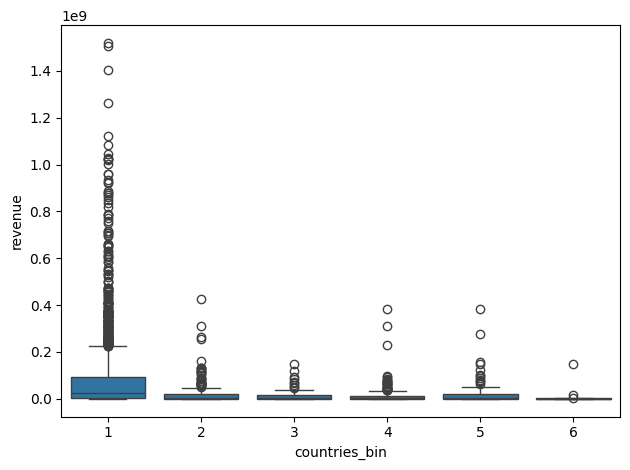

In [ ]:
sns.boxplot(x=data['countries_bin'], y=data['revenue'])
plt.tight_layout()
plt.show()

In [ ]:
data['countries_bin'].corr(data['revenue'])

np.float64(-0.1726534407469445)

In [ ]:
data = data.drop(columns=['countries_names','production_countries'])
data

,budget,genres,homepage,popularity,production_companies,release_date,runtime,spoken_languages,cast,revenue,has_homepage,countries_bin
0,14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,6.575393,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...",2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]","[{'cast_id': 4, 'character': 'Lou', 'credit_id...",12314651,0,1
1,40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,8.248895,"[{'name': 'Walt Disney Pictures', 'id': 2}]",8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]","[{'cast_id': 1, 'character': 'Mia Thermopolis'...",95149435,0,1
2,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,64.299990,"[{'name': 'Bold Films', 'id': 2266}, {'name': ...",10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]","[{'cast_id': 5, 'character': 'Andrew Neimann',...",13092000,1,1
3,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,3.174936,NaN,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...",16000000,1,4
4,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,1.148070,NaN,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]","[{'cast_id': 3, 'character': 'Chun-soo', 'cred...",3923970,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,9.853270,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...",4/22/94,102.0,"[{'iso_639_1': 'en', 'name': 'English'}]","[{'cast_id': 2, 'character': 'Rock Reilly', 'c...",1596687,0,1
2996,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10402, 'n...",NaN,3.727996,"[{'name': 'Memfis Film', 'id': 321}, {'name': ...",3/28/13,102.0,"[{'iso_639_1': 'sv', 'name': 'svenska'}]","[{'cast_id': 5, 'character': 'Bobo', 'credit_i...",180590,0,5
2997,65000000,"[{'id': 80, 'name': 'Crime'}, {'id': 28, 'name...",NaN,14.482345,"[{'name': 'New Line Cinema', 'id': 12}, {'name...",10/11/96,120.0,"[{'iso_639_1': 'en', 'name': 'English'}]","[{'cast_id': 10, 'character': 'Samantha Caine ...",89456761,0,1
2998,42000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",http://www.alongcamepolly.com/,15.725542,"[{'name': 'Jersey Films', 'id': 216}, {'name':...",1/16/04,90.0,"[{'iso_639_1': 'en', 'name': 'English'}]","[{'cast_id': 8, 'character': 'Reuben Feffer', ...",171963386,1,1


REMARKS: As we can see from the boxplot, the countries that not frequently produce movies have tendencies to get lower revenue. Please note that in the algorithm: as the bin number goes higher, the countries production rate are lower. We can also see that countries occurences does have correlation with the revenue, although low but still give signal to predict revenue. It's also showing negative correlation, further proof that as the bin goes higher (less movies produced by that country), the revenue would be lower.

### EDA: SELECTIVE ENCODING FOR PRODUCTION COMPANIES

If we see the features Production Companies, we can see they have dictionaries-like structure but in the string type. We'll attempt to extract the names of the companies and count the frequency of the companies occurences on this dataset. In other words we will score the 'famous level' of that companies and put it in the bin categories. The theory is that companies with more famous than the others tend to have higher revenue. We shall test this theory later in the graphic.

In [ ]:
# Step 1: Fill missing values just in case
data['production_companies'] = data['production_companies'].fillna("[{'name': 'Unknown'}]")

# Step 2: Safely extract actor names
def extract_companies_names(x):
    try:
        parsed = ast.literal_eval(x)
        if isinstance(parsed, list):
            return [d['name'] for d in parsed if isinstance(d, dict) and 'name' in d]
        else:
            return []
    except (ValueError, SyntaxError, TypeError):
        return []

# Step 3: Apply extraction
data['company_names'] = data['production_companies'].apply(extract_companies_names)

# Step 4: Flatten all actor names into one list
all_company = [name for sublist in data['company_names'] for name in sublist]

# Step 5: Count actor frequency
company_counts = Counter(all_company)

# Step 6 (optional): Convert to DataFrame
company_count_df = pd.DataFrame(company_counts.items(), columns=['company_names', 'count']).sort_values(by='count', ascending=False)

# Display top 10 actors
# print(actor_count_df.head(10))
company_count_df

,company_names,count
112,Warner Bros.,202
57,Universal Pictures,188
0,Paramount Pictures,161
7,Unknown,156
13,Twentieth Century Fox Film Corporation,138
...,...,...
1673,Kingsize Entertainment,1
1675,Bombshell Pictures,1
1677,Miller-Milkis Productions,1
1678,MACT Productions,1


In [ ]:
def company_bin_by_max_score(companies, count_dict):
    if not companies:
        return 0  # Unknown or missing
    # Get the highest count among the cast
    max_count = max(count_dict.get(comp, 0) for comp in companies)

    # Assign bins based on max_count
    if 180 <= max_count <= 205:
        return 1
    elif 160 <= max_count < 180:
        return 2
    elif 140 <= max_count < 160:
        return 3
    elif 120 <= max_count < 140:
        return 4
    elif 100 <= max_count < 120:
        return 5
    elif 80 <= max_count < 100:
        return 6
    elif 60 <= max_count < 80:
        return 7
    elif 40 <= max_count < 60:
        return 8
    elif 20 <= max_count < 40:
        return 9
    else:
        return 10  # Rare or unknown

# Step 3: Apply to your DataFrame
data['companies_popularity_bin'] = data['company_names'].apply(lambda x: company_bin_by_max_score(x, company_counts))

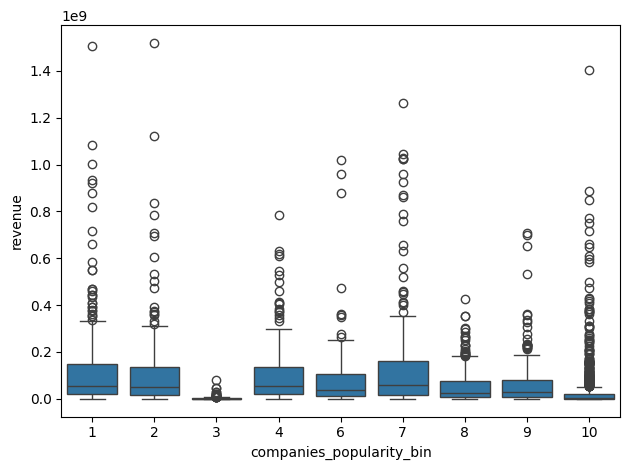

In [ ]:
sns.boxplot(x=data['companies_popularity_bin'], y=data['revenue'])
plt.tight_layout()
plt.show()

In [ ]:
data['companies_popularity_bin'].corr(data['revenue'])

np.float64(-0.20021614106511132)

In [ ]:
data = data.drop(columns=['company_names', 'production_companies'])
data

,budget,genres,homepage,popularity,release_date,runtime,spoken_languages,cast,revenue,has_homepage,countries_bin,companies_popularity_bin
0,14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,6.575393,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]","[{'cast_id': 4, 'character': 'Lou', 'credit_id...",12314651,0,1,2
1,40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,8.248895,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]","[{'cast_id': 1, 'character': 'Mia Thermopolis'...",95149435,0,1,7
2,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,64.299990,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]","[{'cast_id': 5, 'character': 'Andrew Neimann',...",13092000,1,1,10
3,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,3.174936,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...",16000000,1,4,3
4,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,1.148070,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]","[{'cast_id': 3, 'character': 'Chun-soo', 'cred...",3923970,0,5,3
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,9.853270,4/22/94,102.0,"[{'iso_639_1': 'en', 'name': 'English'}]","[{'cast_id': 2, 'character': 'Rock Reilly', 'c...",1596687,0,1,1
2996,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10402, 'n...",NaN,3.727996,3/28/13,102.0,"[{'iso_639_1': 'sv', 'name': 'svenska'}]","[{'cast_id': 5, 'character': 'Bobo', 'credit_i...",180590,0,5,10
2997,65000000,"[{'id': 80, 'name': 'Crime'}, {'id': 28, 'name...",NaN,14.482345,10/11/96,120.0,"[{'iso_639_1': 'en', 'name': 'English'}]","[{'cast_id': 10, 'character': 'Samantha Caine ...",89456761,0,1,7
2998,42000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",http://www.alongcamepolly.com/,15.725542,1/16/04,90.0,"[{'iso_639_1': 'en', 'name': 'English'}]","[{'cast_id': 8, 'character': 'Reuben Feffer', ...",171963386,1,1,10


REMARKS: As we can see from the boxplot, the companies that are not to famous have tendencies to get lower revenue. Please note that in the algorithm: as the bin number goes higher, the companies occurences are lower. We can also see that company occurences does have correlation with the revenue, although low but still give signal to predict revenue. It's also showing negative correlation, further proof that as the bin goes higher (less famous production companies), the revenue would be lower.

### EDA: SELECTIVE ENCODING FOR CAST NAMES

If we see the features Cast Names, we can see they have dictionaries-like structure but in the string type. We'll attempt to extract the names of the artists and count the frequency of the artists occurences on this dataset. In other words we will score the 'famous level' of that artist and put it in the bin categories. The theory is that artist with more famous than the others tend to have higher revenue. We shall test this theory later in the graphic.

In [ ]:
# Step 1: Fill missing values just in case
data['cast'] = data['cast'].fillna("[{'name': 'Unknown'}]")

# Step 2: Safely extract actor names
def extract_actor_names(x):
    try:
        parsed = ast.literal_eval(x)
        if isinstance(parsed, list):
            return [d['name'] for d in parsed if isinstance(d, dict) and 'name' in d]
        else:
            return []
    except (ValueError, SyntaxError, TypeError):
        return []

# Step 3: Apply extraction
data['actor_names'] = data['cast'].apply(extract_actor_names)

# Step 4: Flatten all actor names into one list
all_actors = [name for sublist in data['actor_names'] for name in sublist]

# Step 5: Count actor frequency
actor_counts = Counter(all_actors)

# Step 6 (optional): Convert to DataFrame
actor_count_df = pd.DataFrame(actor_counts.items(), columns=['actor_name', 'count']).sort_values(by='count', ascending=False)

# Display top 10 actors
# print(actor_count_df.head(10))
actor_count_df

,actor_name,count
594,Samuel L. Jackson,30
7008,Robert De Niro,30
749,Morgan Freeman,27
2497,Liam Neeson,25
2129,Bruce Willis,25
...,...,...
16666,Vik Sahay,1
16665,Sarah Manninen,1
16664,Emily Hampshire,1
16663,Jonas Chernick,1


In [ ]:
def actor_bin_by_max_score(actors, count_dict):
    if not actors:
        return 0  # Unknown or missing
    # Get the highest count among the cast
    max_count = max(count_dict.get(actor, 0) for actor in actors)

    # Assign bins based on max_count
    if 25 <= max_count <= 30:
        return 1
    elif 20 <= max_count < 25:
        return 2
    elif 15 <= max_count < 20:
        return 3
    elif 10 <= max_count < 15:
        return 4
    elif 5 <= max_count < 10:
        return 5
    else:
        return 6  # Rare or unknown

# Step 3: Apply to your DataFrame
data['cast_popularity_bin'] = data['actor_names'].apply(lambda x: actor_bin_by_max_score(x, actor_counts))

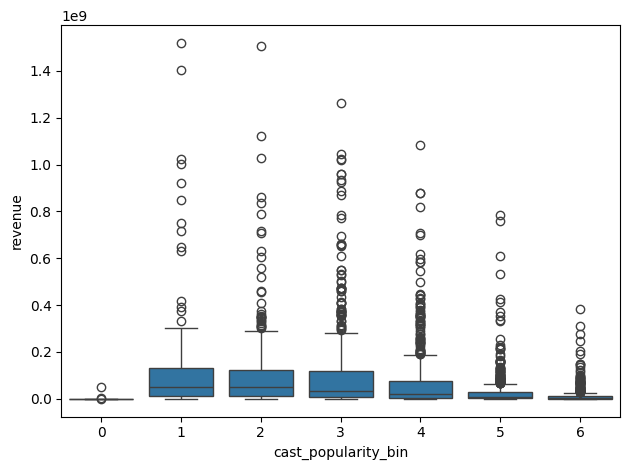

In [ ]:
sns.boxplot(x=data['cast_popularity_bin'], y=data['revenue'])
plt.tight_layout()
plt.show()

In [ ]:
data['cast_popularity_bin'].corr(data['revenue'])

np.float64(-0.25112549221190567)

In [ ]:
data = data.drop(columns=['cast', 'actor_names'])
data

,budget,genres,homepage,popularity,release_date,runtime,spoken_languages,revenue,has_homepage,countries_bin,companies_popularity_bin,cast_popularity_bin
0,14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,6.575393,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",12314651,0,1,2,3
1,40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,8.248895,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",95149435,0,1,7,5
2,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,64.299990,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",13092000,1,1,10,1
3,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,3.174936,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",16000000,1,4,3,6
4,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,1.148070,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",3923970,0,5,3,6
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,9.853270,4/22/94,102.0,"[{'iso_639_1': 'en', 'name': 'English'}]",1596687,0,1,1,3
2996,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10402, 'n...",NaN,3.727996,3/28/13,102.0,"[{'iso_639_1': 'sv', 'name': 'svenska'}]",180590,0,5,10,6
2997,65000000,"[{'id': 80, 'name': 'Crime'}, {'id': 28, 'name...",NaN,14.482345,10/11/96,120.0,"[{'iso_639_1': 'en', 'name': 'English'}]",89456761,0,1,7,1
2998,42000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",http://www.alongcamepolly.com/,15.725542,1/16/04,90.0,"[{'iso_639_1': 'en', 'name': 'English'}]",171963386,1,1,10,3


REMARKS: As we can see from the boxplot, the artist that are not to famous have tendencies to get lower revenue. Please note that in the algorithm: as the bin number goes higher, the artist occurences are lower. We can also see that artist occurences does have correlation with the revenue, although low but still give signal to predict revenue. It's also showing negative correlation, further proof that as the bin goes higher (less famous artist), the revenue would be lower.

### EDA: SELECTIVE ENCODING BASED FOR GENRES

If we see the features Genres, we can see they have dictionaries-like structure but in the string type. We'll attempt to extract all the genres and count the frequency of the that genres occurences on this dataset. After that we will hot encode all the genres and do correlation check to see which one that has strong correlation signal to the revenue target feature. We'll then eliminate any encoded genres that has weak correlation to the target feature.

In [ ]:
data['genres'] = data['genres'].fillna("[{'id': 0, 'name': 'Unknown'}]")

def safe_extract_ids(x):
    try:
        parsed = ast.literal_eval(x)
        if isinstance(parsed, list):
            return [str(d['name']) for d in parsed if isinstance(d, dict) and 'name' in d]
        else:
            return []
    except (ValueError, SyntaxError, TypeError):
        return []

data['genre_ids'] = data['genres'].apply(safe_extract_ids)

mlb = MultiLabelBinarizer()
genre_dummies = pd.DataFrame(mlb.fit_transform(data['genre_ids']),
                              columns=mlb.classes_,
                              index=data.index)

# Step 4: Join back to original DataFrame
data = data.join(genre_dummies)

# data['genre_str'] = data['genre_ids'].apply(lambda ids: ' '.join(ids))

# vectorizer = CountVectorizer()
# genre_vectors = vectorizer.fit_transform(data['genre_str'])

# # Convert to DataFrame
# genre_vectors_df = pd.DataFrame(genre_vectors.toarray(), columns=vectorizer.get_feature_names_out(), index=data.index)

# # Combine with original data
# data = pd.concat([data, genre_vectors_df], axis=1)
data


,budget,genres,homepage,popularity,release_date,runtime,spoken_languages,revenue,has_homepage,countries_bin,...,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,Unknown,War,Western
0,14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,6.575393,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",12314651,0,1,...,0,0,0,0,0,0,0,0,0,0
1,40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,8.248895,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",95149435,0,1,...,0,0,0,1,0,0,0,0,0,0
2,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,64.299990,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",13092000,1,1,...,0,0,0,0,0,0,0,0,0,0
3,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,3.174936,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",16000000,1,4,...,0,0,0,0,0,0,1,0,0,0
4,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,1.148070,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",3923970,0,5,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,9.853270,4/22/94,102.0,"[{'iso_639_1': 'en', 'name': 'English'}]",1596687,0,1,...,0,0,0,1,0,0,0,0,0,0
2996,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10402, 'n...",NaN,3.727996,3/28/13,102.0,"[{'iso_639_1': 'sv', 'name': 'svenska'}]",180590,0,5,...,0,1,0,0,0,0,0,0,0,0
2997,65000000,"[{'id': 80, 'name': 'Crime'}, {'id': 28, 'name...",NaN,14.482345,10/11/96,120.0,"[{'iso_639_1': 'en', 'name': 'English'}]",89456761,0,1,...,0,0,1,0,0,0,1,0,0,0
2998,42000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",http://www.alongcamepolly.com/,15.725542,1/16/04,90.0,"[{'iso_639_1': 'en', 'name': 'English'}]",171963386,1,1,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   budget                    3000 non-null   int64  
 1   genres                    3000 non-null   object 
 2   homepage                  946 non-null    object 
 3   popularity                3000 non-null   float64
 4   release_date              3000 non-null   object 
 5   runtime                   2998 non-null   float64
 6   spoken_languages          2980 non-null   object 
 7   revenue                   3000 non-null   int64  
 8   has_homepage              3000 non-null   int64  
 9   countries_bin             3000 non-null   int64  
 10  companies_popularity_bin  3000 non-null   int64  
 11  cast_popularity_bin       3000 non-null   int64  
 12  genre_ids                 3000 non-null   object 
 13  Action                    3000 non-null   int64  
 14  Adventur

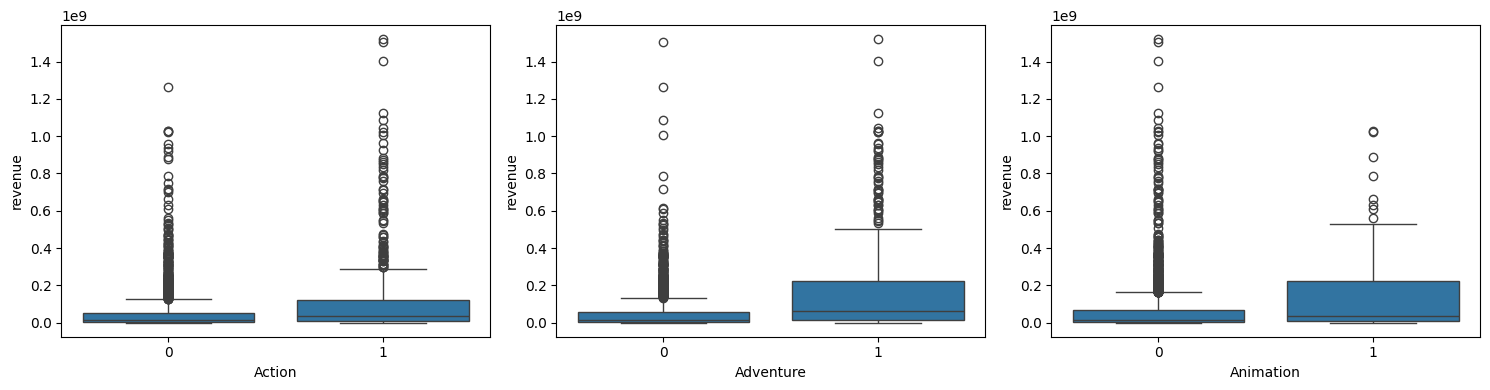

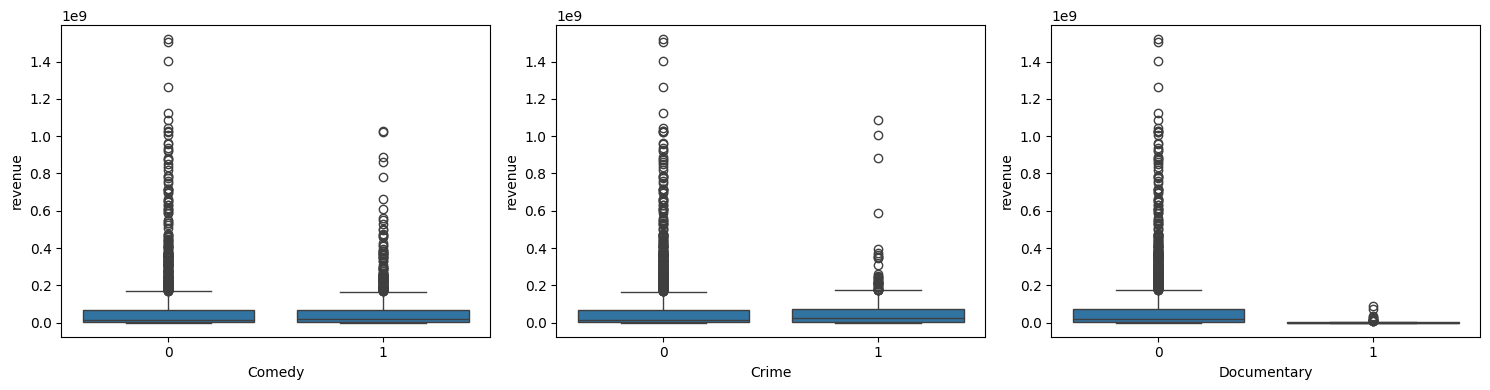

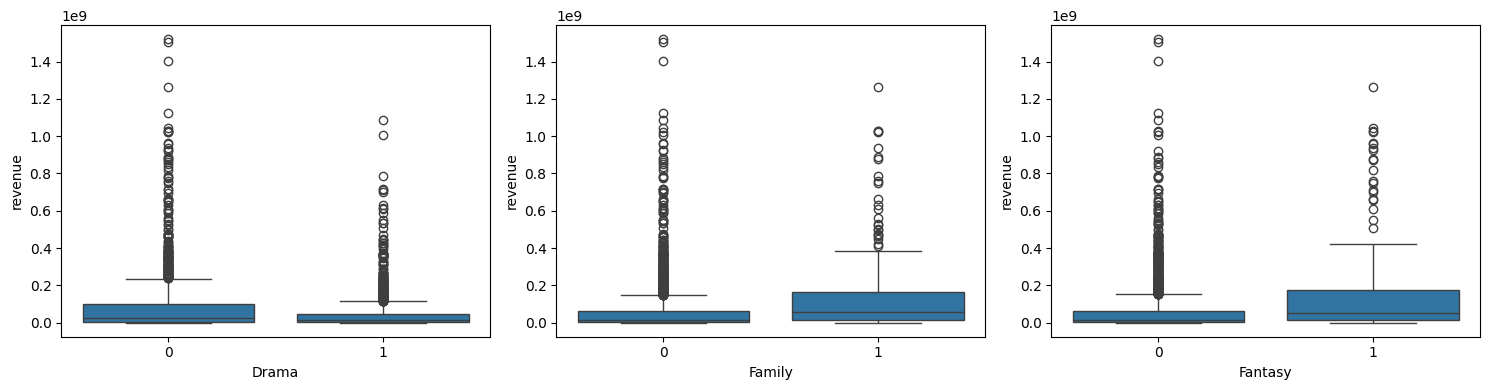

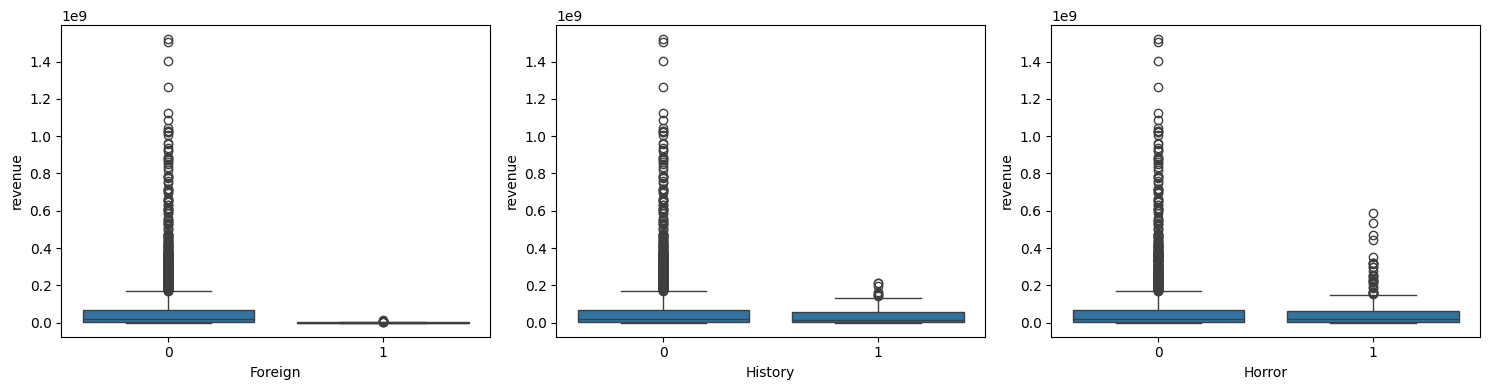

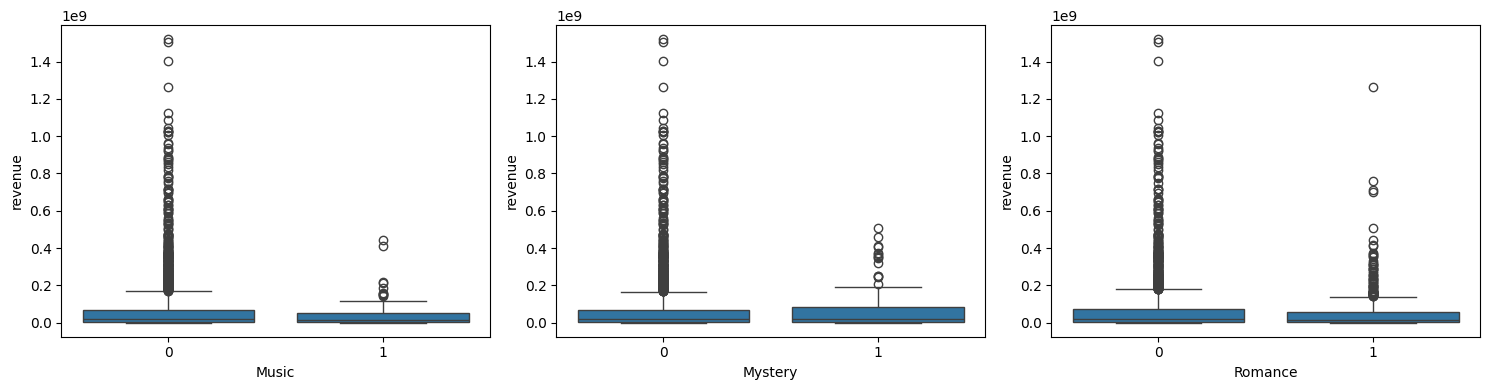

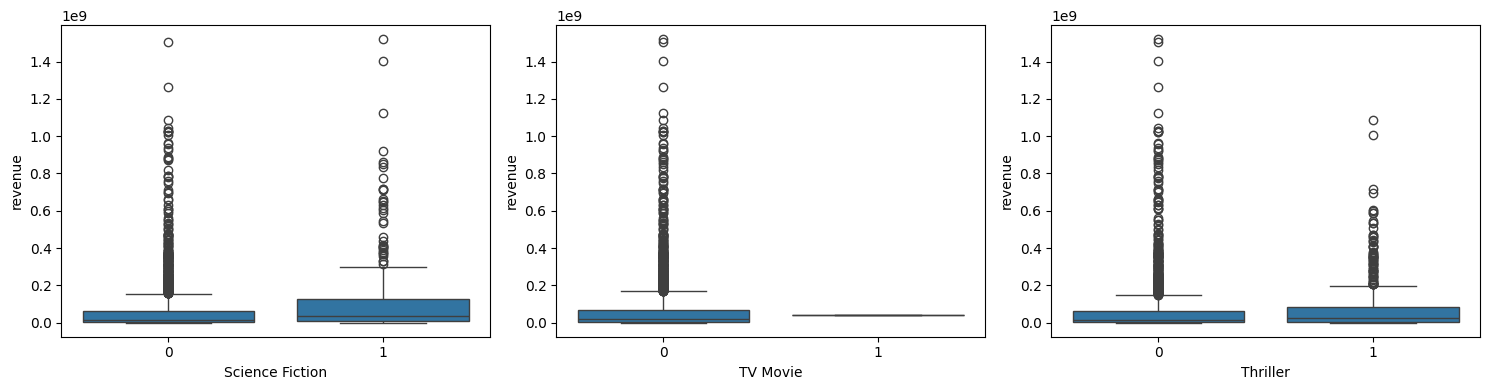

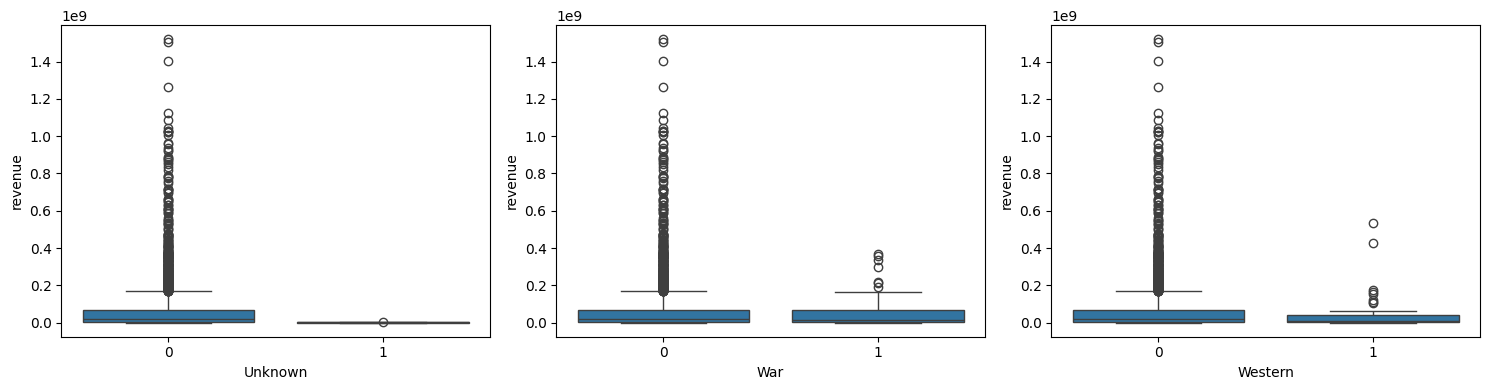

<Figure size 1500x400 with 0 Axes>

In [ ]:
plt.figure(figsize=(15, 4))
index__  = 1

for i in range(13,34):
  if index__ % 3 != 0:
    plt.subplot(1,3,index__)
    sns.boxplot(x=data.iloc[:, i], y=data['revenue'])
    index__ += 1
  elif index__ % 3 == 0:
    plt.subplot(1,3,index__)
    sns.boxplot(x=data.iloc[:, i], y=data['revenue'])
    plt.tight_layout()
    plt.show()
    index__  = 1
    plt.figure(figsize=(15, 4))

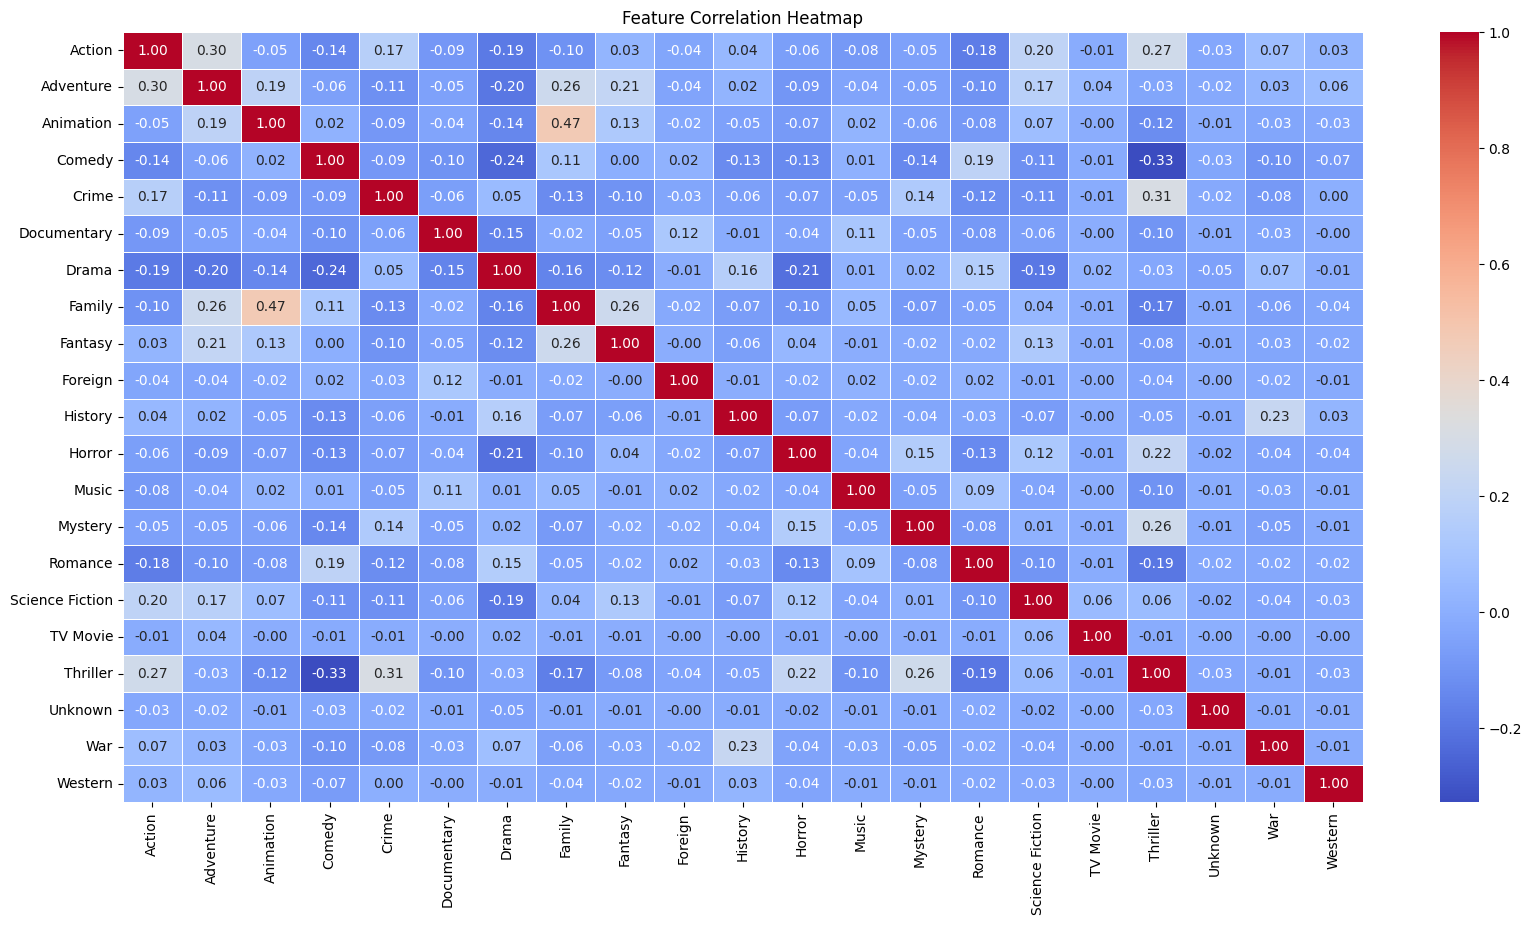

In [ ]:
data_corr = data.iloc[:, 13:34]
corr_matrix = data_corr.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
corr_genres = data.iloc[:, 7:34].drop(columns=['genre_ids']).corr()['revenue'].sort_values(ascending=False)
drop_feature = []
for i, j in corr_genres.items():
  if abs(j) < 0.10:
    drop_feature.append(i)

drop_feature

['Thriller',
 'TV Movie',
 'Western',
 'Mystery',
 'Crime',
 'War',
 'Unknown',
 'Comedy',
 'Music',
 'Horror',
 'History',
 'Foreign',
 'Romance',
 'Documentary']

In [ ]:
data = data.drop(columns=['spoken_languages', 'homepage', 'genres', 'genre_ids'])
data = data.drop(columns=drop_feature)
data

,budget,popularity,release_date,runtime,revenue,has_homepage,countries_bin,companies_popularity_bin,cast_popularity_bin,Action,Adventure,Animation,Drama,Family,Fantasy,Science Fiction
0,14000000,6.575393,2/20/15,93.0,12314651,0,1,2,3,0,0,0,0,0,0,0
1,40000000,8.248895,8/6/04,113.0,95149435,0,1,7,5,0,0,0,1,1,0,0
2,3300000,64.299990,10/10/14,105.0,13092000,1,1,10,1,0,0,0,1,0,0,0
3,1200000,3.174936,3/9/12,122.0,16000000,1,4,3,6,0,0,0,1,0,0,0
4,0,1.148070,2/5/09,118.0,3923970,0,5,3,6,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0,9.853270,4/22/94,102.0,1596687,0,1,1,3,0,0,0,0,0,0,0
2996,0,3.727996,3/28/13,102.0,180590,0,5,10,6,0,0,0,1,0,0,0
2997,65000000,14.482345,10/11/96,120.0,89456761,0,1,7,1,1,0,0,0,0,0,0
2998,42000000,15.725542,1/16/04,90.0,171963386,1,1,10,3,0,0,0,0,0,0,0


In [ ]:
data = data.dropna()
data

,budget,popularity,release_date,runtime,revenue,has_homepage,countries_bin,companies_popularity_bin,cast_popularity_bin,Action,Adventure,Animation,Drama,Family,Fantasy,Science Fiction
0,14000000,6.575393,2/20/15,93.0,12314651,0,1,2,3,0,0,0,0,0,0,0
1,40000000,8.248895,8/6/04,113.0,95149435,0,1,7,5,0,0,0,1,1,0,0
2,3300000,64.299990,10/10/14,105.0,13092000,1,1,10,1,0,0,0,1,0,0,0
3,1200000,3.174936,3/9/12,122.0,16000000,1,4,3,6,0,0,0,1,0,0,0
4,0,1.148070,2/5/09,118.0,3923970,0,5,3,6,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0,9.853270,4/22/94,102.0,1596687,0,1,1,3,0,0,0,0,0,0,0
2996,0,3.727996,3/28/13,102.0,180590,0,5,10,6,0,0,0,1,0,0,0
2997,65000000,14.482345,10/11/96,120.0,89456761,0,1,7,1,1,0,0,0,0,0,0
2998,42000000,15.725542,1/16/04,90.0,171963386,1,1,10,3,0,0,0,0,0,0,0


In [ ]:
# WE CHECK IF MONTH AND YEAR HAS CORRELATION WITH THE REVENUE, IT TURNS OUT THERE'S NO RELATION
# data['release_date'] = pd.to_datetime(data['release_date'], format='%m/%d/%y', errors='coerce')

# data['release_month'] = data['release_date'].dt.month
# data['release_year'] = data['release_date'].dt.year
# data = data.drop(columns='release_date')
# data

In [ ]:
# corr_matrix = data.corr(numeric_only=True)

# # Plot heatmap
# plt.figure(figsize=(20,10))
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
# plt.title("Feature Correlation Heatmap")
# plt.show()

In [ ]:
# data = data.drop(columns=['release_month','release_year'])
data = data.drop(columns=['release_date'])
data

,budget,popularity,runtime,revenue,has_homepage,countries_bin,companies_popularity_bin,cast_popularity_bin,Action,Adventure,Animation,Drama,Family,Fantasy,Science Fiction
0,14000000,6.575393,93.0,12314651,0,1,2,3,0,0,0,0,0,0,0
1,40000000,8.248895,113.0,95149435,0,1,7,5,0,0,0,1,1,0,0
2,3300000,64.299990,105.0,13092000,1,1,10,1,0,0,0,1,0,0,0
3,1200000,3.174936,122.0,16000000,1,4,3,6,0,0,0,1,0,0,0
4,0,1.148070,118.0,3923970,0,5,3,6,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0,9.853270,102.0,1596687,0,1,1,3,0,0,0,0,0,0,0
2996,0,3.727996,102.0,180590,0,5,10,6,0,0,0,1,0,0,0
2997,65000000,14.482345,120.0,89456761,0,1,7,1,1,0,0,0,0,0,0
2998,42000000,15.725542,90.0,171963386,1,1,10,3,0,0,0,0,0,0,0


## NOISE DATA CLEANING

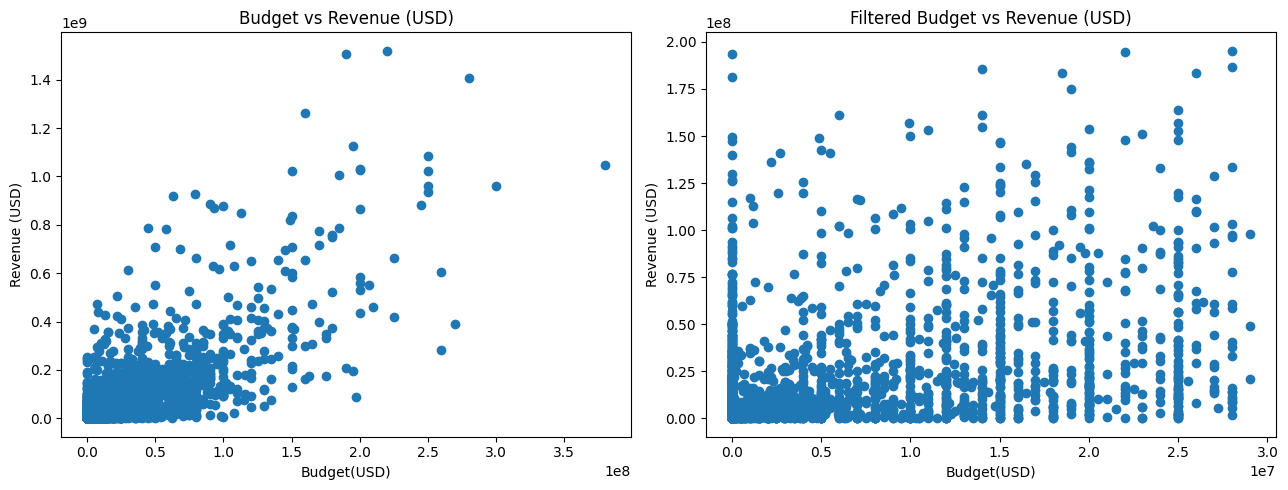

In [ ]:
a = data.loc[(data['revenue'] < 2e8) & (data['budget'] < 0.3e8), :]
plt.figure(figsize=(13, 5))

plt.subplot(121)
plt.scatter(data['budget'], data['revenue'])
plt.title('Budget vs Revenue (USD)')
plt.xlabel('Budget(USD)')
plt.ylabel('Revenue (USD)')

plt.subplot(122)
plt.scatter(a['budget'], a['revenue'])
plt.title('Filtered Budget vs Revenue (USD)')
plt.xlabel('Budget(USD)')
plt.ylabel('Revenue (USD)')

plt.tight_layout()
plt.show()

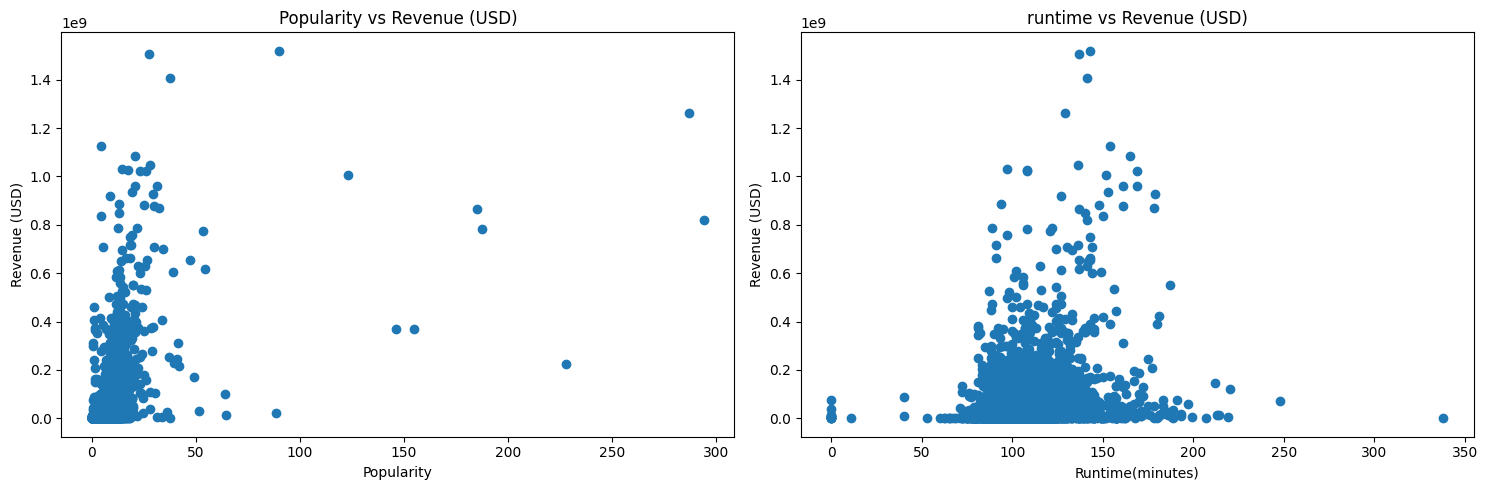

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(121)
plt.scatter(data['popularity'], data['revenue'])
plt.title('Popularity vs Revenue (USD)')
plt.xlabel('Popularity')
plt.ylabel('Revenue (USD)')

plt.subplot(122)
plt.scatter(data['runtime'], data['revenue'])
plt.title('runtime vs Revenue (USD)')
plt.xlabel('Runtime(minutes)')
plt.ylabel('Revenue (USD)')

plt.tight_layout()
plt.show()

In [ ]:
# features_a = ['budget', 'popularity', 'runtime']
# iso = IsolationForest(contamination=0.02, random_state=42)
# data['outlier_flag_a'] = iso.fit_predict(data[features_a])

In [ ]:
# data = data.loc[(data['outlier_flag_a'] == 1), :]
# data

In [ ]:
# Remove budget/revenue = 0
data = data[(data['budget'] > 0) & (data['revenue'] > 0)]
data = data[(data['popularity'] < 100)]

# Compute ROI
data['roi'] = data['revenue'] / data['budget']

# Filter bombs and unicorns (for clean regression)
# data = data[(data['roi'] >= 0.5) & (data['roi'] <= 10)]

data['log_revenue'] = np.log1p(data['revenue'])
data

,budget,popularity,runtime,revenue,has_homepage,countries_bin,companies_popularity_bin,cast_popularity_bin,Action,Adventure,Animation,Drama,Family,Fantasy,Science Fiction,roi,log_revenue
0,14000000,6.575393,93.0,12314651,0,1,2,3,0,0,0,0,0,0,0,0.879618,16.326300
1,40000000,8.248895,113.0,95149435,0,1,7,5,0,0,0,1,1,0,0,2.378736,18.370959
2,3300000,64.299990,105.0,13092000,1,1,10,1,0,0,0,1,0,0,0,3.967273,16.387512
3,1200000,3.174936,122.0,16000000,1,4,3,6,0,0,0,1,0,0,0,13.333333,16.588099
5,8000000,0.743274,83.0,3261638,0,4,3,3,0,1,1,0,1,0,0,0.407705,14.997740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2992,1135654,3.878515,149.0,1213880,0,1,10,6,1,1,0,1,1,1,0,1.068882,14.009333
2993,60000000,14.092373,128.0,219417255,1,1,9,3,0,0,0,1,0,0,0,3.656954,19.206486
2997,65000000,14.482345,120.0,89456761,0,1,7,1,1,0,0,0,0,0,0,1.376258,18.309266
2998,42000000,15.725542,90.0,171963386,1,1,10,3,0,0,0,0,0,0,0,4.094366,18.962792


REMARKS: Upon inspection on some numerical features like popularity level, runtime and budget we identified some noises and abnormalities. Especially when we take a look at scatterplot of Revenue vs Budget graphic, then we can notice there are lots of movies that have 0 value budget or 0 value revenue. The data also quite clustered in one sections, we will also apply log transform to alleviate this situation. Trial using grouped outliers removal was proven to be detrimental to the Machine Learning, and therefore we abandoned this method.

## MACHINE LEARNING MODELLING

Now, finally we can do Machine Learning modelling. We'll use 4 models namely: `RandomForestRegressor`, `XGBoostRegressor`, `GradientBoostingRegressor` and `LightGBMRegressor`. We'll check the RMSLE score and choose which one of them is better.

In [ ]:
x_main = data.drop(columns=['log_revenue', 'revenue', 'roi'])
y_main = data['log_revenue']

x_train, x_test, y_train, y_test = train_test_split(x_main, y_main, test_size=0.2, random_state=42)

In [ ]:
model_rf = RandomForestRegressor(n_estimators=150, random_state=42, verbose=2)
model_rf.fit(x_train, y_train)
y_pred_rf = model_rf.predict(x_test)

rmsle_score = root_mean_squared_log_error(y_test, y_pred_rf)
print(f'rmsle_score is: {rmsle_score}')


building tree 1 of 150
building tree 2 of 150
building tree 3 of 150
building tree 4 of 150
building tree 5 of 150
building tree 6 of 150
building tree 7 of 150
building tree 8 of 150
building tree 9 of 150
building tree 10 of 150
building tree 11 of 150
building tree 12 of 150
building tree 13 of 150
building tree 14 of 150
building tree 15 of 150
building tree 16 of 150
building tree 17 of 150
building tree 18 of 150
building tree 19 of 150
building tree 20 of 150
building tree 21 of 150
building tree 22 of 150
building tree 23 of 150
building tree 24 of 150
building tree 25 of 150
building tree 26 of 150
building tree 27 of 150
building tree 28 of 150
building tree 29 of 150
building tree 30 of 150
building tree 31 of 150
building tree 32 of 150
building tree 33 of 150
building tree 34 of 150
building tree 35 of 150
building tree 36 of 150
building tree 37 of 150
building tree 38 of 150
building tree 39 of 150
building tree 40 of 150
building tree 41 of 150
building tree 42 of 150
b

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.4s


building tree 45 of 150
building tree 46 of 150
building tree 47 of 150
building tree 48 of 150
building tree 49 of 150
building tree 50 of 150
building tree 51 of 150
building tree 52 of 150
building tree 53 of 150
building tree 54 of 150
building tree 55 of 150
building tree 56 of 150
building tree 57 of 150
building tree 58 of 150
building tree 59 of 150
building tree 60 of 150
building tree 61 of 150
building tree 62 of 150
building tree 63 of 150
building tree 64 of 150
building tree 65 of 150
building tree 66 of 150
building tree 67 of 150
building tree 68 of 150
building tree 69 of 150
building tree 70 of 150
building tree 71 of 150
building tree 72 of 150
building tree 73 of 150
building tree 74 of 150
building tree 75 of 150
building tree 76 of 150
building tree 77 of 150
building tree 78 of 150
building tree 79 of 150
building tree 80 of 150
building tree 81 of 150
building tree 82 of 150
building tree 83 of 150
building tree 84 of 150
building tree 85 of 150
building tree 86

[Parallel(n_jobs=1)]: Done 150 out of 150 | elapsed:    1.4s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 150 out of 150 | elapsed:    0.0s finished


In [ ]:
model_xgb = XGBRegressor(verbosity=3)
model_xgb.fit(x_train, y_train)
y_pred_xgb = model_xgb.predict(x_test)

rmsle_score = root_mean_squared_log_error(y_test, y_pred_xgb)
print(f'rmsle_score is: {rmsle_score}')

[16:10:16] ======== Monitor (0): HostSketchContainer ========
[16:10:16] AllReduce: 0.000522s, 1 calls @ 522us

[16:10:16] MakeCuts: 0.000553s, 1 calls @ 553us

[16:10:16] DEBUG: /workspace/src/gbm/gbtree.cc:130: Using tree method: 0
[16:10:16] ======== Monitor (0): Learner ========
[16:10:16] Configure: 0.021308s, 1 calls @ 21308us

[16:10:16] EvalOneIter: 0.000377s, 100 calls @ 377us

[16:10:16] GetGradient: 0.000669s, 100 calls @ 669us

[16:10:16] PredictRaw: 0.000106s, 100 calls @ 106us

[16:10:16] UpdateOneIter: 0.101284s, 100 calls @ 101284us

[16:10:16] ======== Monitor (0): GBTree ========
[16:10:16] BoostNewTrees: 0.078572s, 100 calls @ 78572us

[16:10:16] CommitModel: 4.2e-05s, 100 calls @ 42us

[16:10:16] ======== Monitor (0): HistUpdater ========
[16:10:16] BuildHistogram: 0.010597s, 500 calls @ 10597us

[16:10:16] EvaluateSplits: 0.045196s, 600 calls @ 45196us

[16:10:16] InitData: 0.001571s, 100 calls @ 1571us

[16:10:16] InitRoot: 0.006206s, 100 calls @ 6206us

[16:10:16

In [ ]:
model_gbr = GradientBoostingRegressor(n_estimators=150, random_state=42, verbose=3)
model_gbr.fit(x_train, y_train)
y_pred_gbr = model_gbr.predict(x_test)

rmsle_score = root_mean_squared_log_error(y_test, abs(y_pred_gbr))
print(f'rmsle_score is: {rmsle_score}')

      Iter       Train Loss   Remaining Time 
         1           6.1069            1.41s
         2           5.5880            0.93s
         3           5.1731            0.76s
         4           4.8177            0.68s
         5           4.5383            0.63s
         6           4.3023            0.59s
         7           4.1040            0.57s
         8           3.9134            0.55s
         9           3.7594            0.53s
        10           3.6348            0.52s
        11           3.5046            0.51s
        12           3.4071            0.50s
        13           3.3158            0.49s
        14           3.2420            0.48s
        15           3.1690            0.48s
        16           3.0988            0.47s
        17           3.0414            0.46s
        18           2.9918            0.45s
        19           2.9472            0.45s
        20           2.9075            0.44s
        21           2.8731            0.43s
        2

In [ ]:
model_light = LGBMRegressor(n_estimators=120, max_depth=35, random_state=42, verbosity=2)
model_light.fit(x_train, y_train)
y_pred_light = model_light.predict(x_test)

rmsle_score = root_mean_squared_log_error(y_test, abs(y_pred_light))
print(f'rmsle_score is: {rmsle_score}')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.833477
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.512622
[LightGBM] [Debug] init for col-wise cost 0.001054 seconds, init for row-wise cost 0.000381 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001146 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 626
[LightGBM] [Info] Number of data points in the train set: 1743, number of used features: 14
[LightGBM] [Info] Start training from score 16.718301
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 7
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 7
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 7
[LightGBM] [Debug

REMARKS: Based on 4 models above, we can see that `RandomForestRegressor` has lower RMSLE score than the others. With `RandomForestRegressor` we managed to predict the test data with RMSLE score of 0.1706 which implies that on average, the model's predicted revenue is within ~17% of the actual revenue, on a multiplicative scale (log error). Which is quite good for a real-world noisy dataset like movies, where:
1. Marketing,
2. Star power,
3. Cultural trends
Can all affect performance unpredictably. Let's check the model and see if the model is overfitting or not.

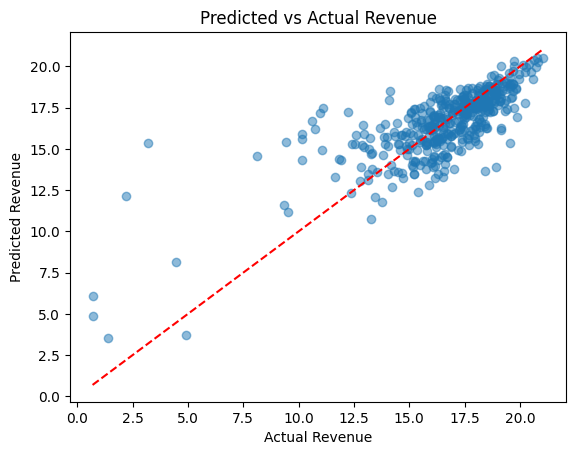

In [ ]:
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title('Predicted vs Actual Revenue')
plt.show()

COMMENTS: We can see from the graph that:
1. Most points cluster tightly around the red line at higher values (15–21), showing the model learns well in that range.
2. There’s no U-shape or wild spread on either side — a good sign.
3. The bias is low — predictions aren't consistently over or under.

So, although the model is struggling with the lower revenue value, it didn't overfit and managed to predict the test set with RMSLE 0.1706 which is good enough for this real-world dataset that has lots of noises.
